# Figure 3C. Functional annotation

In [61]:
### Load packages
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import glob

In [62]:
# map from original id to species
seqhasher = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/hq_hc_viruses_seqhasher.tsv.gz', separator='\t').unique('original_id')
uhvdb_mapping = pl.concat([
    pl.read_csv('../figure_1/uhvdb_virus_db_results/uhvdb_2026-03-26/uhvdb_mapping.tsv.gz', separator='\t'),
    pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/new_hq_hc_viruses_mapping.tsv.gz', separator='\t')
])
seqhash_reps = seqhasher.filter(pl.col('original_id').is_in(set(uhvdb_mapping['original_id']))).unique('original_id').rename({'original_id':'seqhash_rep'})
uhvdb_source_meta = pl.read_csv('../figure_1/uhvdb_final_metadata.tsv', separator='\t')
genomovar_info = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/genomovars_cluster/hq_hc_genomovars_info.tsv.gz', separator='\t')
uhvdb_species_info = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/species_cluster/hq_hc_species_info.tsv.gz', separator='\t')
aaicluster = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/aaicluster/hq_hc_species_aai_clusters.tsv.gz', separator='\t')

combined = (
    uhvdb_source_meta
        .join(seqhasher.unique('original_id'), left_on='seq_name', right_on='original_id', how='left')
        .join(seqhasher.with_columns(pl.col('original_id').str.extract(r"^(.*)\|provirus", group_index=1).fill_null(pl.col("original_id"))), left_on='seq_name', right_on='original_id', how='left')
        .with_columns(
            pl.when(pl.col('hash').is_not_null()).then(pl.col('hash')).otherwise(pl.col('hash_right')).alias('hash')
        )
        .join(seqhash_reps, on='hash', how='left')
        .join(uhvdb_mapping.unique('original_id'), left_on='seqhash_rep', right_on='original_id', how='left')
        .join(genomovar_info[['uhvdb_id', 'votu_rep']], left_on='new_id', right_on='uhvdb_id', how='left').rename({'votu_rep':'genomovar_rep'})
        .join(uhvdb_species_info[['uhvdb_id', 'votu_rep']], left_on='genomovar_rep', right_on='uhvdb_id', how='left')
        .join(aaicluster, left_on='votu_rep', right_on='uhvdb_id', how='left')
        .filter((pl.col('seq_name') == pl.col('seqhash_rep')) & (pl.col('new_id') == pl.col('genomovar_rep')))
        .unique('seq_name')
)

In [63]:
## load uhvdb protein outputs
prot_lst = []

for file in glob.glob('../figure_1/*_results/*_outputs/function/hq_hc_genomovars_prothash.tsv.gz'):
    df = pl.read_csv(file, separator='\t')
    prot_lst.append(df)

combined_prot = (
    pl.concat(prot_lst)
        .unique('protein_id')
        .with_columns([
            pl.col('protein_id').str.replace(r"_[^_]*$", "").alias('genomovar_id')
        ])
        .filter(pl.col('genomovar_id').is_in(set(combined['genomovar_rep'])))
)

In [64]:
# genomovar unique proteins
uhvdb_proteins = set(combined_prot['hash'])
print(f"Total unique proteins in genomovars: {len(uhvdb_proteins)}")

Total unique proteins in genomovars: 15114978


In [65]:
# ## load bakta protein outputs
# bakta_lst = []

# for file in glob.glob('../figure_1/*_results/*_outputs/function/new_proteins_bakta.tsv.gz'):
#     df = pl.read_csv(file, separator='\t', ignore_errors=True, skip_rows=5, columns=['Locus Tag', 'Query Cov', 'Subject Cov', 'Id', 'Accession'],
#         schema_overrides={'Locus Tag': pl.Utf8, 'Query Cov': pl.Float64, 'Subject Cov': pl.Float64, 'Id': pl.Float64, 'Accession': pl.Utf8})
#     bakta_lst.append(df)

# combined_bakta = (
#     pl.concat(bakta_lst)
#         .filter(pl.col('Accession') != '-')
#         .filter(pl.col('Locus Tag').is_in(uhvdb_proteins))
#         .unique('Locus Tag')
# )

# combined_bakta.write_csv('bakta_hits.tsv', separator='\t')
# del bakta_lst

In [66]:
combined_bakta = pl.read_csv('bakta_hits.tsv', separator='\t')
bakta_stats = (
    combined_bakta
        .with_columns([
            pl.when(pl.col('Accession').str.contains('UniRef') & (pl.col('Query Cov') >= 1) & (pl.col('Subject Cov') >= 1) & (pl.col('Id') >= 1))
                .then(pl.lit('UniRef100'))
                .when((pl.col('Accession').str.contains('UniRef')) & (pl.col('Query Cov') >= 0.8) & (pl.col('Subject Cov') >= 0.8) & (pl.col('Id') >= 0.9))
                .then(pl.lit('UniRef90'))
                .when((pl.col('Accession').str.contains('UniRef')) & (pl.col('Query Cov') >= 0.8) & (pl.col('Subject Cov') >= 0.8) & (pl.col('Id') >= 0.5))
                .then(pl.lit('UniRef50'))
                .when((pl.col('Accession').str.contains('UniRef')) & (pl.col('Query Cov') >= 0.8) & (pl.col('Subject Cov') >= 0.8) & (pl.col('Id') >= 0.3))
                .then(pl.lit('UniRef30'))
                .otherwise(pl.lit('No match'))
                .alias('uniprot_hit_level')
        ])
        .group_by('uniprot_hit_level').len().sort('uniprot_hit_level')
)

In [67]:
# ## load foldseek protein outputs
# foldseek_lst = []

# for file in glob.glob('../figure_1/*_results/*_outputs/function/new_proteins_foldseek.tsv.gz'):
#     df = pl.read_csv(file, separator='\t', ignore_errors=True, has_header=False)
#     foldseek_lst.append(df)

# combined_foldseek = (
#     pl.concat(foldseek_lst)
#         .filter(pl.col('column_1').is_in(uhvdb_proteins))
#         .unique('column_1')
# )

# combined_foldseek.write_csv('foldseek_hits.tsv', separator='\t')
# del foldseek_lst

In [68]:
combined_foldseek = pl.read_csv('foldseek_hits.tsv', separator='\t').unique('column_1')

In [69]:
# ## load interproscan protein outputs
# ips_lst = []

# for file in glob.glob('../figure_1/*_results/*_outputs/function/new_proteins_interproscan.tsv.gz'):
#     df = pl.read_csv(file, separator='\t', ignore_errors=True, has_header=False, columns=['column_1', 'column_2', 'column_4', 'column_5'])
#     ips_lst.append(df)

# combined_interproscan = (
#     pl.concat(ips_lst)
#         .filter(pl.col('column_1').is_in(uhvdb_proteins))
# )

# combined_interproscan.write_csv('interproscan_hits.tsv', separator='\t')
# del ips_lst

In [70]:
combined_interproscan = pl.read_csv('interproscan_hits.tsv', separator='\t').unique('column_1')

In [71]:
# ## load pharokka protein outputs
# pharokka_lst = []

# for file in glob.glob('../figure_1/*_results/*_outputs/function/new_proteins_pharokka.tsv.gz'):
#     df = pl.read_csv(file, separator='\t', ignore_errors=True)
#     pharokka_lst.append(df)

# combined_pharokka = (
#     pl.concat(pharokka_lst)
#         .filter(pl.col('phrog') != 'No_PHROGs_HMM')
#         .filter(pl.col('ID').is_in(uhvdb_proteins))
#         .unique('ID')
# )

# combined_pharokka.write_csv('pharokka_hits.tsv', separator='\t')
# del pharokka_lst

In [72]:
combined_pharokka = pl.read_csv('pharokka_hits.tsv', separator='\t')

In [73]:
pharokka_stats = (
    combined_pharokka
        .with_columns([
            pl.when(pl.col('annot') == 'hypothetical protein')
                .then(pl.lit('hypothetical'))
                .otherwise(pl.lit('function'))
                .alias('phrog_hit_type')
        ])
        .group_by('phrog_hit_type').len().sort('phrog_hit_type')
)

In [74]:
# ## load pharokka protein outputs
# phold_lst = []

# for file in glob.glob('../figure_1/*_results/*_outputs/function/new_proteins_phold.tsv.gz'):
#     df = pl.read_csv(file, separator='\t', ignore_errors=True, columns=['cds_id', 'phrog', 'function', 'product'])
#     phold_lst.append(df)

# combined_phold = (
#     pl.concat(phold_lst)
#         .filter(pl.col('phrog') != 'No_PHROG')
#         .filter(pl.col('cds_id').is_in(uhvdb_proteins))
#         .unique('cds_id')
# )
# combined_phold.write_csv('phold_hits.tsv', separator='\t')
# del phold_lst

In [75]:
combined_phold = pl.read_csv('phold_hits.tsv', separator='\t')

In [76]:
phold_stats = (
    combined_phold
        .with_columns([
            pl.when(pl.col('function') == 'unknown function')
                .then(pl.lit('hypothetical'))
                .otherwise(pl.lit('function'))
                .alias('phrog_hit_type')
        ])
        .group_by('phrog_hit_type').len().sort('phrog_hit_type')
)

In [77]:
# ## load empathi protein outputs
# empathi_lst = []

# for file in glob.glob('../figure_1/*_results/*_outputs/function/new_proteins_empathi.csv.gz'):
#     df = pl.read_csv(file, ignore_errors=True, columns=['', 'Annotation'])
#     empathi_lst.append(df)

# combined_empathi = (
#     pl.concat(empathi_lst)
#         .filter(pl.col('Annotation') != 'unknown')
#         .filter(pl.col('').is_in(uhvdb_proteins))
#         .unique('')
# )

# combined_empathi.write_csv('empathi_hits.tsv', separator='\t')
# del empathi_lst

In [78]:
combined_empathi = pl.read_csv('empathi_hits.tsv', separator='\t').unique(pl.col(''))

In [79]:
total_proteins = len(uhvdb_proteins)

In [80]:
uniprot_stats = (
    pl.DataFrame({
        'method': ['UniRef100', 'UniRef90', 'UniRef50', 'UniRef30', 'Foldseek', 'InterProScan'],
        'count': [
            bakta_stats.filter(pl.col('uniprot_hit_level') == 'UniRef100')['len'][0],
            bakta_stats.filter(pl.col('uniprot_hit_level') == 'UniRef90')['len'][0],
            bakta_stats.filter(pl.col('uniprot_hit_level') == 'UniRef50')['len'][0],
            bakta_stats.filter(pl.col('uniprot_hit_level') == 'UniRef30')['len'][0],
            len(combined_foldseek),
            len(combined_interproscan)
        ]
    })
    .with_columns([
        pl.col('count').cum_sum().alias('cumulative_count')
    ])
)
uniprot_stats

method,count,cumulative_count
str,i64,i64
"""UniRef100""",539878,539878
"""UniRef90""",3122098,3661976
"""UniRef50""",4056973,7718949
"""UniRef30""",2889298,10608247
"""Foldseek""",172636,10780883
"""InterProScan""",1642941,12423824


In [81]:
(539878 + 3122098 + 4056973 + 2889298 + 172636) / 15114978

0.7132582660722364

In [82]:
1642941/15114978

0.10869622172126218

In [83]:
phrog_hits = (
    set(combined_pharokka.filter(pl.col('annot') != 'hypothetical protein')['ID'])
    .union(combined_phold.filter(pl.col('function') != 'unknown function')['cds_id'])
)
phage_stats = (
    pl.DataFrame({
        'method': ['Pharokka', 'Phold', 'Empathi'],
        'count': [
            pharokka_stats.filter(pl.col('phrog_hit_type') == 'function')['len'][0],
            phold_stats.filter(pl.col('phrog_hit_type') == 'function')['len'][0],
            combined_empathi.filter(~pl.col('').is_in(phrog_hits)).height
        ]
    })
    .with_columns([
        pl.col('count').cum_sum().alias('cumulative_count')
    ])
)
phage_stats

method,count,cumulative_count
str,i64,i64
"""Pharokka""",5747230,5747230
"""Phold""",1173706,6920936
"""Empathi""",4814061,11734997


In [84]:
pharokka_stats.filter(pl.col('phrog_hit_type') == 'hypothetical')['len'][0],
phold_stats.filter(pl.col('phrog_hit_type') == 'hypothetical')['len'][0]

684830

In [90]:
(5747230 + 1173706) / 15114978

0.4578859459802059

In [89]:
(5747230 + 1173706 + pharokka_stats.filter(pl.col('phrog_hit_type') == 'hypothetical')['len'][0] + phold_stats.filter(pl.col('phrog_hit_type') == 'hypothetical')['len'][0]) / 15114978

0.6872902494466085

In [91]:
4814061 / 15114978

0.31849606397045366

In [92]:
(5747230 + 1173706 + 4814061) / 15114978

0.7763820099506595

/tmp/ipykernel_67897/2105108991.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sort_values('cumulative_count')['method'])


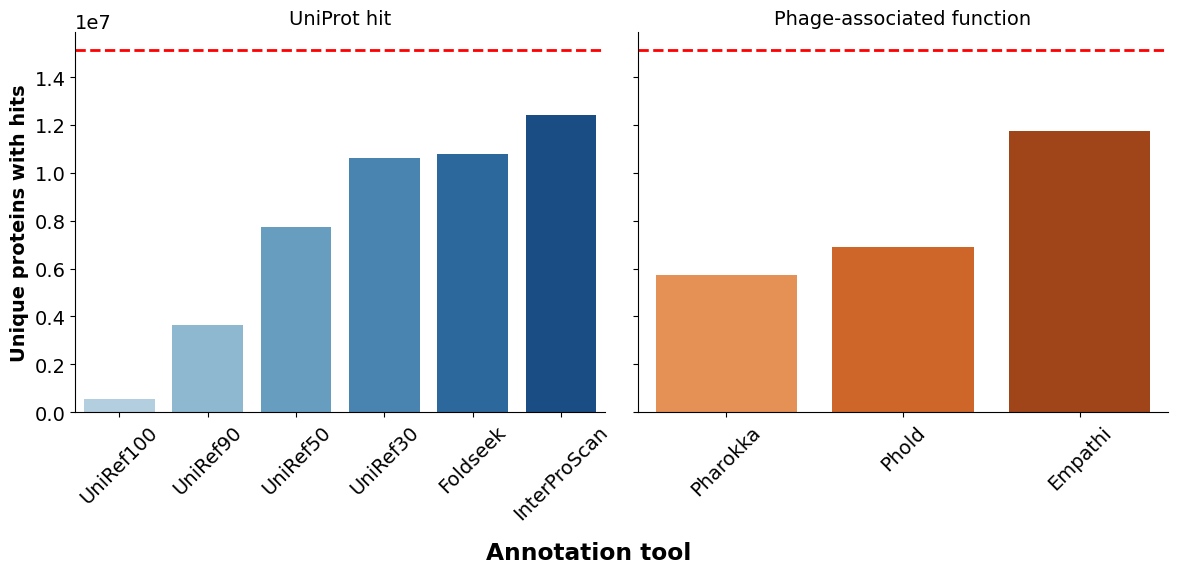

In [86]:
plt.rcParams.update({'font.size': 14})

plot_df = pl.concat([
    uniprot_stats.select(['method', 'cumulative_count']).with_columns(pl.lit('UniProt hit').alias('category')),
    phage_stats.select(['method', 'cumulative_count']).with_columns(pl.lit('Phage-associated function').alias('category'))
]).to_pandas()

# Order methods by increasing count within each facet
plot_df['method'] = (
    plot_df.groupby('category', group_keys=False)
    .apply(lambda g: g.sort_values('cumulative_count')['method'])
    .reindex(plot_df.index)
)

# Color palettes: blue shades for UniProt methods, orange shades for Phage methods
uniprot_methods = (
    plot_df[plot_df['category'] == 'UniProt hit']
    .sort_values('cumulative_count')['method']
    .tolist()
)
phage_methods = (
    plot_df[plot_df['category'] == 'Phage-associated function']
    .sort_values('cumulative_count')['method']
    .tolist()
)

blue_shades = sns.color_palette('Blues', n_colors=len(uniprot_methods) + 2)[2:]
orange_shades = sns.color_palette('Oranges', n_colors=len(phage_methods) + 2)[2:]

palette = {
    **{m: c for m, c in zip(uniprot_methods, blue_shades)},
    **{m: c for m, c in zip(phage_methods, orange_shades)}
}

# Facet by UniProt / Phage
g = sns.catplot(
    data=plot_df,
    kind='bar',
    x='method',
    y='cumulative_count',
    hue='method',
    col='category',
    col_order=['UniProt hit', 'Phage-associated function'],
    palette=palette,
    dodge=False,
    sharex=False,
    sharey=True,
    height=6,
    aspect=1.0
)

g.set_ylabels('Unique proteins with hits', fontdict={'fontweight': 'bold'})
g.set_titles('{col_name}')

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')

g.fig.subplots_adjust(top=0.85)
g.fig.supxlabel('Annotation tool', y=0.04, fontweight='bold')

# Keep one legend outside
if g._legend is not None:
    g._legend.set_bbox_to_anchor((1.02, 0.95))

# add a horizontal line representing total proteins
for ax in g.axes.flat:
    ax.axhline(y=total_proteins, color='red', linestyle='--', linewidth=2)

plt.tight_layout()
plt.show()

In [87]:
## load card protein outputs
card_lst = []

for file in glob.glob('../figure_1/*_results/*_outputs/function/new_proteins_card.tsv.gz'):
    df = pl.read_csv(file, separator='\t', ignore_errors=True, has_header=False, columns=['column_1'])
    card_lst.append(df)

combined_card = (
    pl.concat(card_lst)
        .filter(pl.col('column_1').is_in(uhvdb_proteins))
        .unique('column_1')
)
combined_card

column_1
str
"""9631974e0868067e9ed59f58897328…"
"""facda1c7d5979317e3a2a83a6750a4…"
"""42f83f2c69b735f6e67abab3d82c08…"
"""5eeb864f485164ccf6d1dba6d09823…"
"""c773f5da7c9bfc98122c9e5b339a13…"
…
"""7fcb0ef0034cf5430a829a3c69f3c2…"
"""dec5aaae8c3e222813f88ea4d357ff…"
"""dd043fbbd04d19101083093415ddae…"


In [88]:
## load vfdb protein outputs
vfdb_lst = []

for file in glob.glob('../figure_1/*_results/*_outputs/function/new_proteins_vfdb.tsv.gz'):
    df = pl.read_csv(file, separator='\t', ignore_errors=True, has_header=False, columns=['column_1'])
    vfdb_lst.append(df)

combined_vfdb = (
    pl.concat(vfdb_lst)
        .filter(pl.col('column_1').is_in(uhvdb_proteins))
        .unique('column_1')
)
combined_vfdb

column_1
str
"""0db66d66a474760c8bf25496ac7737…"
"""daaac93803c40d7a8a11ff0f733701…"
"""12c1fb8d3b3379fdce2d45253cd5ec…"
"""53ab16cfc644ce3e1968b168ccd5d7…"
"""3ca8c20d3366890b367e3c53501e22…"
…
"""5b456ed4e2b89877ac33b17417a1b5…"
"""ddd56cec62e3be152bd681e957d177…"
"""127aca59d468d32d0d2d1f5c3adda6…"
